In [2]:
import sys
sys.path.append('..')
import shap
import numpy as np
import matplotlib.pyplot as plt
import joblib
from src.data_pipeline import run_pipeline
from src.features import FEATURE_NAMES

In [3]:
model = joblib.load('../models/credit_model.pkl')
scaler = joblib.load('../models/scaler.pkl')
_, X_test, _, y_test = run_pipeline()

1/5 Loading data from database...
2/5 Cleaning data...
3/5 Engineering features...
4/5 Building feature matrix...
5/5 Splitting and scaling...
Train: (119999, 10), Test: (30000, 10)
Default rate - train 0.067 test 0.067


## Creating the explainer
TreeExplainer is designed for tree based models such as xgboost
It uses the tree structure to compute exact SHAP values in polynomial time instead of exponential

Kernel explorer works on any model but its much slower so i didnt use it

In [4]:
explainer = shap.TreeExplainer(model)

##Compute Shap values on a 1000 row sample
idx = np.random.choice(len(X_test), size = 1000, replace = False)

X_sample = X_test[idx]
shap_values = explainer.shap_values(X_sample)

print(f'shap_values shape: {shap_values.shape}')
##This should be (1000: 10): one shap value per row per featuer

print(f'baseline prediction: {explainer.expected_value:.4f}')
##This will be the avg predicted default across all training data

shap_values shape: (1000, 10)
baseline prediction: 0.0339


### This is a Summary plot

I read it like this: each row is a feature, each dot is one of the 1000 customers, Right means the feature increased on the default probability, Left means it has decreased, red means the customer has a High value for that feature, blue means a Low value

example - red dots at the far right for 'total_late_payments' =
customer with many late payments have a lot higher predicted default risk

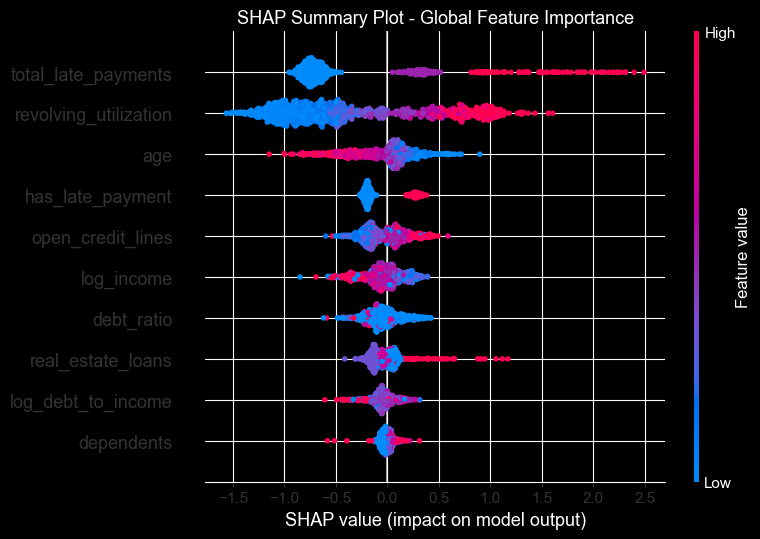

In [6]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, feature_names = FEATURE_NAMES, show = False)
plt.title('SHAP Summary Plot - Global Feature Importance', fontsize = 13)
plt.tight_layout()
plt.savefig('../docs/shap_summary.png', dpi = 150, bbox_inches = 'tight')
plt.show()

Customer default probability: 0.9853


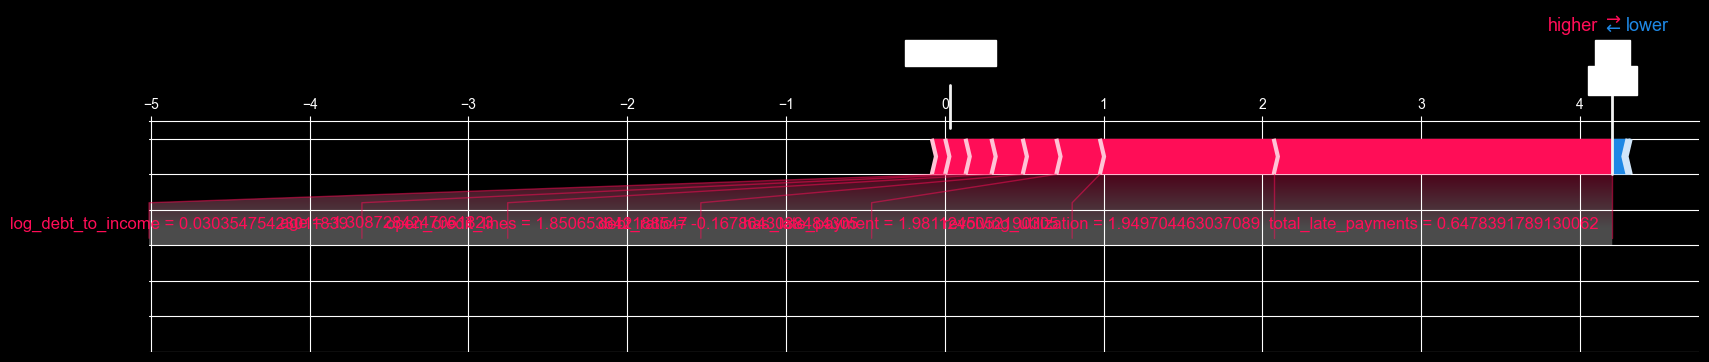

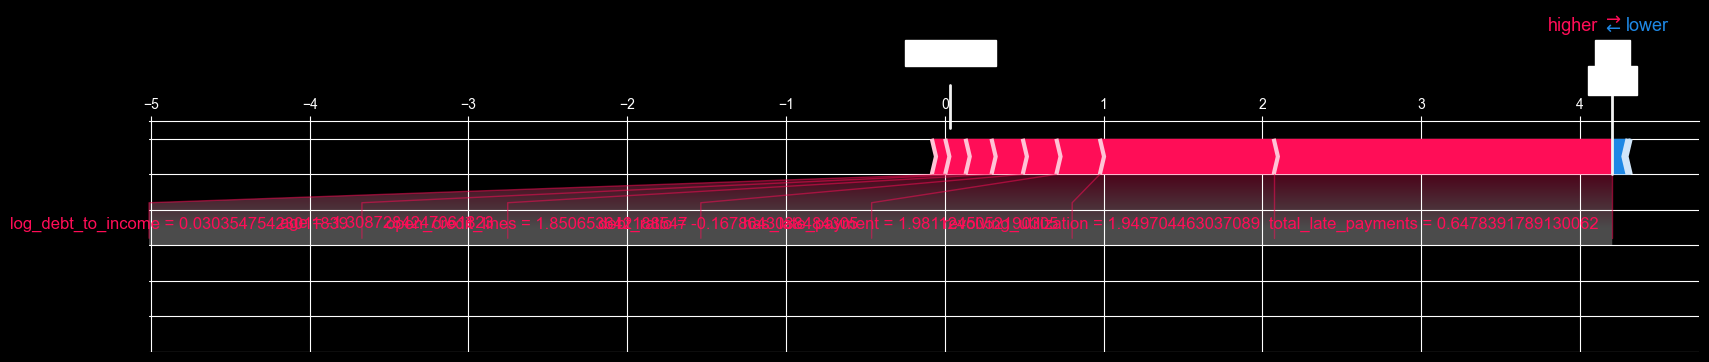

In [8]:
## Individual force plot for a 'high-risk customer'

## This is so i can find the customer with the highest predicted probability to default on the loan

proba = model.predict_proba(X_test)[:,1]
high_risk_pos = np.argmax(proba)
print(f'Customer default probability: {proba[high_risk_pos]:.4f}')

# Get shap value for the customer

single_shap = explainer.shap_values(X_test[high_risk_pos:high_risk_pos+1])[0]

# Force plot

shap.force_plot(
    explainer.expected_value,
    single_shap,
    X_test[high_risk_pos],
    feature_names = FEATURE_NAMES,
    matplotlib = True,
    show = False
)
plt.savefig('../shap_force_plot_high_risk.png',dpi=150,bbox_inches = 'tight')
plt.show()

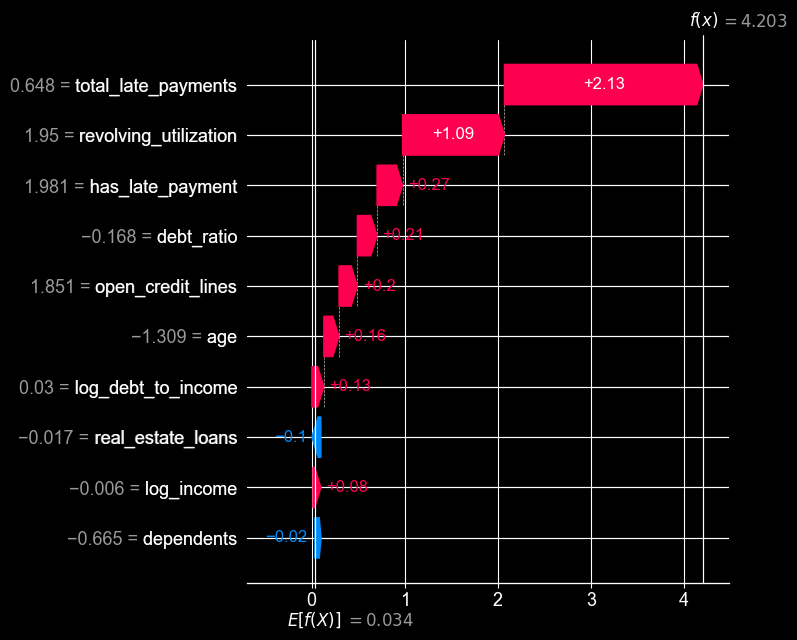

In [9]:
## Waterfall plot - Like force plot but cleaner

shap_exp = shap.Explanation(
    values = single_shap,
    base_values = explainer.expected_value,
    data = X_test[high_risk_pos],
    feature_names = FEATURE_NAMES,
)

plt.figure(figsize= (10 , 6))
shap.plots.waterfall(shap_exp, show = False)
plt.tight_layout()
plt.savefig('../docs/shap_waterfall.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [10]:
## Save the explainer for use via API and other stuff idk

joblib.dump(explainer, '../models/shap_ explainer.pkl')
print('Explainer saved to ../models/shap_ explainer.pkl')

Explainer saved to ../models/shap_ explainer.pkl
